<a href="https://colab.research.google.com/github/gigihArmy/Fungi-Image-Classification/blob/main/Edible_and_poisonous_fungi_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fungi Images Classification (Edible & Non-Edible)

In [1]:
!pip install opendatasets

## Library

In [2]:
import os
import opendatasets as od
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adamax

## Load Datasets

In [3]:
od.download('https://www.kaggle.com/datasets/marcosvolpato/edible-and-poisonous-fungi/data')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: g
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/marcosvolpato/edible-and-poisonous-fungi


100%|██████████| 257M/257M [00:00<00:00, 969MB/s] 


In [ ]:
os.listdir('/content/edible-and-poisonous-fungi')

['poisonous sporocarp',
 'poisonous mushroom sporocarp',
 'edible sporocarp',
 'edible mushroom sporocarp']

In [ ]:
data_folder_path = '/content/edible-and-poisonous-fungi'
classes = ['edible sporocarp', 'poisonous sporocarp']
label_map = {sub: i for i, sub in enumerate(classes)}

#list
images = []
labels = []

#resizing images iteration
for sub in classes:
  sub_path = os.path.join(data_folder_path, sub)
  for filename in os.listdir(sub_path):
    img_path = os.path.join(sub_path, filename)
    #read images
    img = cv2.imread(img_path)
    if img is not None:
      resized = cv2.resize(img, (128, 128))
      images.append(resized)
      labels.append(label_map[sub])

#convert to arrays
images = np.array(images)
labels = np.array(labels)

In [ ]:
label_map

{'edible sporocarp': 0, 'poisonous sporocarp': 1}

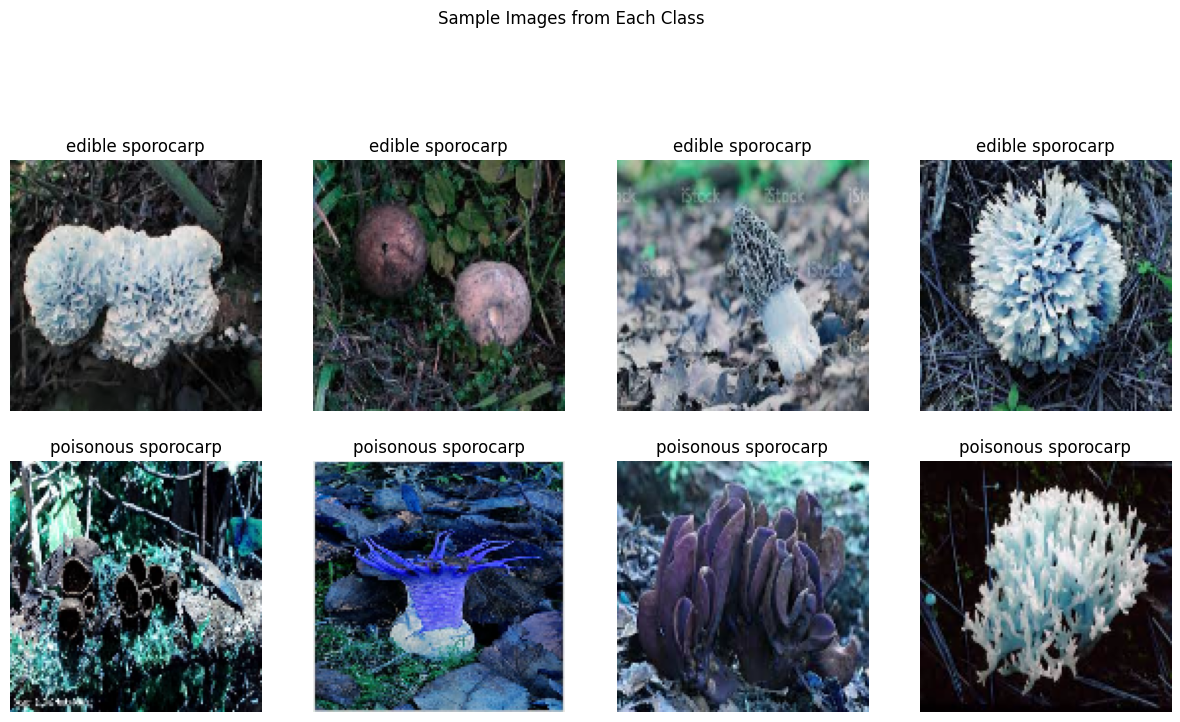

In [ ]:
plt.figure(figsize = (15,15))
for i, label in enumerate(classes):
    class_indices = np.where(labels == label_map[label])[0]
    for j in range(4):
        plt.subplot(4, 4, i*4 + j+1)
        plt.imshow(images[class_indices[j]])
        plt.title(label)
        plt.axis('off')
plt.suptitle('Sample Images from Each Class')
plt.show()

## Pre-processing

In [ ]:
#split data train & temp
X_train, X_temp, y_train, y_temp = train_test_split(images, labels, test_size=0.3, random_state=42, stratify=labels)

#split validation & test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

Train set: (1278, 128, 128, 3)
Validation set: (274, 128, 128, 3)
Test set: (274, 128, 128, 3)


In [ ]:
#Normalizing
X_train = X_train / 255.0
X_temp = X_temp / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

## Modelling

In [ ]:
cnn = Sequential([
    #layer 1
    Conv2D(filters=16, kernel_size=(3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(pool_size=(2,2)),
    #layer 2
    Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    #layer 3
    Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(classes), activation='sigmoid')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,629,602 (6.22 MB)

 Trainable params: 1,629,602 (6.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#model compile
cnn.compile(optimizer=Adamax(learning_rate=0.001),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

#callback
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_model.keras',
    save_best_only=True,
    monitor='val_loss',
)

In [ ]:
history = cnn.fit(X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=12,
        batch_size=20,
        callbacks=[callback, model_checkpoint])

Epoch 1/12
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 312ms/step - accuracy: 0.6939 - loss: 0.6188 - val_accuracy: 0.7555 - val_loss: 0.4998
Epoch 2/12
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 280ms/step - accuracy: 0.7534 - loss: 0.5025 - val_accuracy: 0.7628 - val_loss: 0.4592
Epoch 3/12
64/64 ━━━━━━━━━━━━━━━━━━━━ 21s 282ms/step - accuracy: 0.7918 - loss: 0.4522 - val_accuracy: 0.8029 - val_loss: 0.4634
Epoch 4/12
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 287ms/step - accuracy: 0.8039 - loss: 0.4445 - val_accuracy: 0.8066 - val_loss: 0.4188
Epoch 5/12
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 280ms/step - accuracy: 0.7947 - loss: 0.4371 - val_accuracy: 0.7993 - val_loss: 0.4074
Epoch 6/12
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 276ms/step - accuracy: 0.8389 - loss: 0.3691 - val_accuracy: 0.8139 - val_loss: 0.4180
Epoch 7/12
64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 304ms/step - accuracy: 0.8588 - loss: 0.3329 - val_accuracy: 0.8248 - val_loss: 0.3944
Epoch 8/12
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 283ms/step - accuracy: 0.8984 - loss: 0.2708 - val_accu

## Model Evaluation

In [ ]:
cnn.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 171ms/step - accuracy: 0.7516 - loss: 0.5775


[0.5581780672073364, 0.7481752038002014]

In [ ]:
y_pred = cnn.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes, target_names=classes))

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step
                     precision    recall  f1-score   support

   edible sporocarp       0.55      0.32      0.40        73
poisonous sporocarp       0.78      0.91      0.84       201

           accuracy                           0.75       274
          macro avg       0.67      0.61      0.62       274
       weighted avg       0.72      0.75      0.72       274



Text(0.5, 1.0, 'Confusion Matrix')

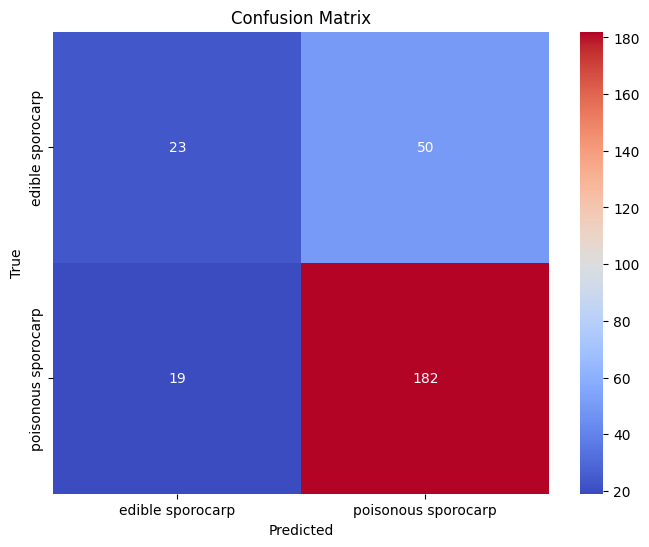

In [ ]:
#heatmap visualization
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

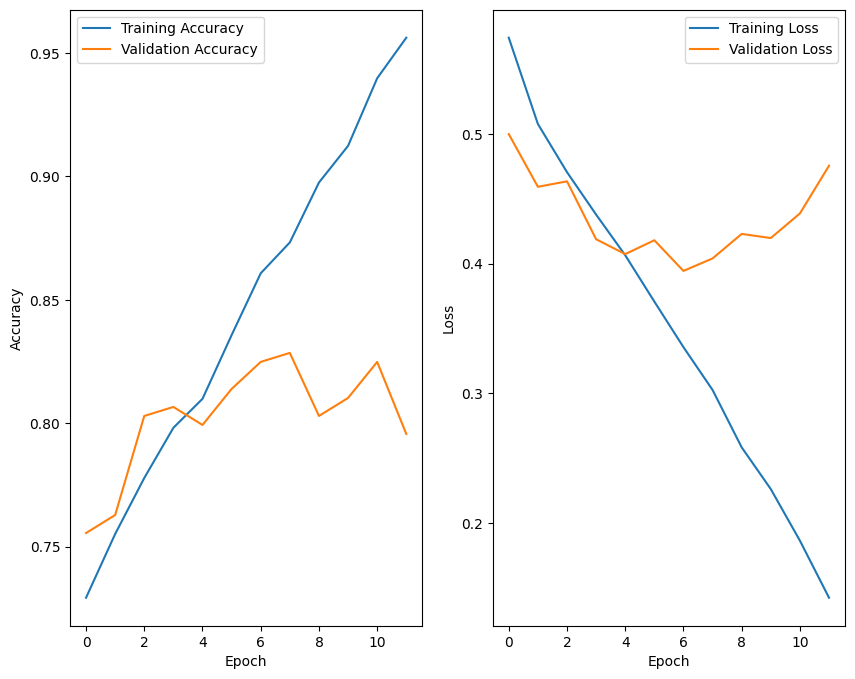

In [ ]:
#plot accuracy
plt.figure(figsize=(10, 8))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

#plot loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Inference

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step


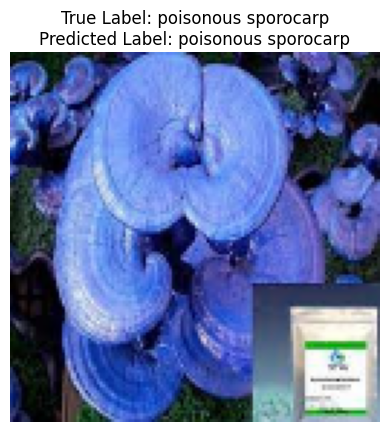

In [ ]:
#load model
model = tf.keras.models.load_model('best_model.keras')

sample_image = X_test[0]
sample_label = y_test[0]

sample_image = np.expand_dims(sample_image, axis=0)
prediction = model.predict(sample_image)
predicted_index = np.argmax(prediction, axis=1)[0]
predicted_label = classes[predicted_index]
true_class_label = classes[sample_label]

#display
plt.imshow(sample_image[0])
plt.title(f"True Label: {true_class_label}\nPredicted Label: {predicted_label}")
plt.axis('off')
plt.show()

## Data Augmentation

In [ ]:
data_aug = Sequential([
    layers.RandomFlip('horizontal',
                      input_shape=(128,128,3)),
    layers.RandomZoom(0.7),
])

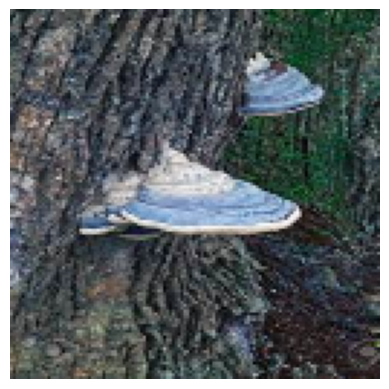

In [ ]:
plt.axis('off')
plt.imshow((X_test)[1])

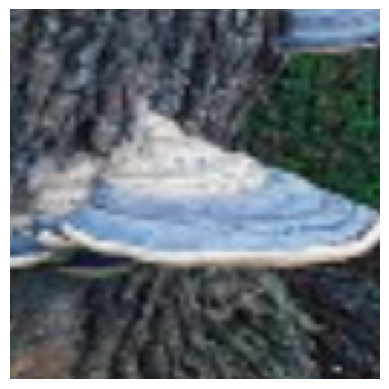

In [ ]:
plt.axis('off')
plt.imshow(data_aug(X_test)[1])

In [ ]:
sec_cnn = Sequential([
    data_aug,
    #layer 1
    Conv2D(filters=16, kernel_size=(3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(pool_size=(2,2)),
    #layer 2
    Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    #layer 3
    Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Dropout(0.2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(classes), activation='sigmoid')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
sec_cnn.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

sec_model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='sec_best_model.keras',
    save_best_only=True,
    monitor='val_loss',
)

In [ ]:
sec_history = sec_cnn.fit(X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=12,
        batch_size=20,
        callbacks=[callback, sec_model_checkpoint])

Epoch 1/12
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 372ms/step - accuracy: 0.7527 - loss: 0.5278 - val_accuracy: 0.7774 - val_loss: 0.4791
Epoch 2/12
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 495ms/step - accuracy: 0.7479 - loss: 0.5213 - val_accuracy: 0.7555 - val_loss: 0.5379
Epoch 3/12
64/64 ━━━━━━━━━━━━━━━━━━━━ 44s 546ms/step - accuracy: 0.7495 - loss: 0.5199 - val_accuracy: 0.8248 - val_loss: 0.4883
Epoch 4/12
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 517ms/step - accuracy: 0.7560 - loss: 0.5069 - val_accuracy: 0.7956 - val_loss: 0.4502
Epoch 5/12
64/64 ━━━━━━━━━━━━━━━━━━━━ 28s 327ms/step - accuracy: 0.7764 - loss: 0.4888 - val_accuracy: 0.8102 - val_loss: 0.4621
Epoch 6/12
64/64 ━━━━━━━━━━━━━━━━━━━━ 22s 345ms/step - accuracy: 0.7878 - loss: 0.4790 - val_accuracy: 0.7993 - val_loss: 0.4548
Epoch 7/12
64/64 ━━━━━━━━━━━━━━━━━━━━ 22s 347ms/step - accuracy: 0.7845 - loss: 0.4874 - val_accuracy: 0.7993 - val_loss: 0.4759
Epoch 8/12
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 358ms/step - accuracy: 0.7539 - loss: 0.5100 - val_accu

In [ ]:
sec_cnn.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.7509 - loss: 0.5189


[0.5210798382759094, 0.7408758997917175]

In [ ]:
sec_y_pred = sec_cnn.predict(X_test)
sec_y_pred_classes = np.argmax(sec_y_pred, axis=1)

print(classification_report(y_test, sec_y_pred_classes, target_names=classes))

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 189ms/step
                     precision    recall  f1-score   support

   edible sporocarp       0.52      0.30      0.38        73
poisonous sporocarp       0.78      0.90      0.84       201

           accuracy                           0.74       274
          macro avg       0.65      0.60      0.61       274
       weighted avg       0.71      0.74      0.72       274



## MobileNetV2 Transfer Learning

In [4]:
import numpy as np
import cv2
import PIL.Image as Image
import os
import matplotlib.pyplot as plt

import tensorflow as tf
import tf_keras
import tensorflow_hub as hub
from tensorflow import keras
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Sequential

In [5]:
IMAGE_SHAPE = (224,224)
data_folder_path = '/content/edible-and-poisonous-fungi'

images = []
labels = []

for sub in os.listdir(data_folder_path):
  file_path = os.path.join(data_folder_path, sub)
  for file in os.listdir(file_path):
    img_path = os.path.join(file_path, file)
    img = cv2.imread(img_path)
    if img is not None:
      resized = cv2.resize(img, IMAGE_SHAPE)
      images.append(resized)
      if sub.startswith('edible'):
        labels.append(0)
      else:
        labels.append(1)

images = np.array(images)
labels = np.array(labels) ## 0=edible 1=poisonous

In [72]:
#distribution classes
print('Total: ', len(labels))
print('Edible: ', len(labels[labels==0]))
print('Poisonous: ', len(labels[labels==1]))

Total:  3401
Edible:  1181
Poisonous:  2220


In [6]:
#split
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

#normalizing
X_train_scaled = X_train/255
X_test_scaled = X_test/255

In [7]:
base = MobileNetV2(
    input_shape=IMAGE_SHAPE+(3,),
    include_top=False,
    weights='imagenet'
)
base.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [8]:
model = Sequential()
model.add(base)
model.add(GlobalAveragePooling2D())
model.add(Dense(2, activation='sigmoid'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train_scaled, y_train, epochs=10)

Epoch 1/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.6386 - loss: 0.7007
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.7374 - loss: 0.5112
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.7699 - loss: 0.4718
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.7847 - loss: 0.4410
Epoch 5/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.8089 - loss: 0.4189
Epoch 6/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8169 - loss: 0.4006
Epoch 7/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8315 - loss: 0.3806
Epoch 8/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8479 - loss: 0.3569
Epoch 9/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.8241 - loss: 0.3531
Epoch 10/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.8462 - loss: 0.3427


In [11]:
model.evaluate(X_test_scaled, y_test)

22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 472ms/step - accuracy: 0.7464 - loss: 0.5137


[0.5241987705230713, 0.7518355250358582]

In [13]:
y_pred = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes, target_names=['edible', 'poisonous']))

              precision    recall  f1-score   support

      edible       0.69      0.51      0.59       236
   poisonous       0.77      0.88      0.82       445

    accuracy                           0.75       681
   macro avg       0.73      0.69      0.70       681
weighted avg       0.74      0.75      0.74       681



In [10]:
model.save('transfer_learning_model.keras')

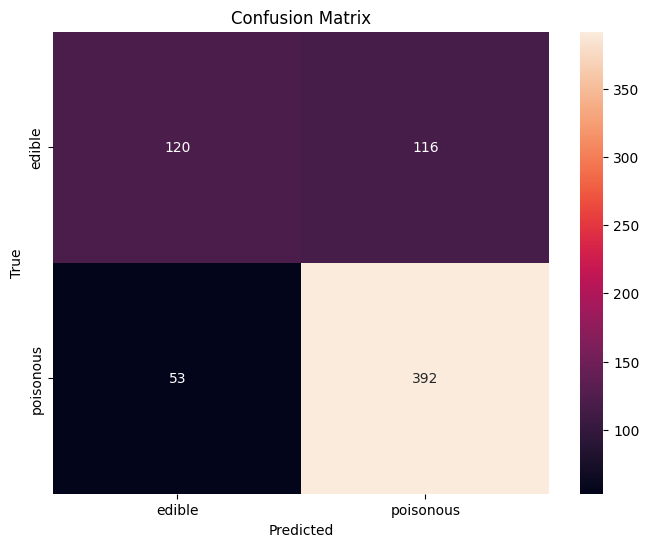

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_classes), fmt='d', annot=True, xticklabels=['edible','poisonous'], yticklabels=['edible','poisonous'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()